In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [11]:
dane00=pd.read_csv('pokemon_data.csv')

In [12]:
#dwukolorowybarh

counts_type1 = dane00['type1'].value_counts()
counts_type2 = dane00['type2'].value_counts()
types_counts_total = counts_type1.add(counts_type2, fill_value=0) 

df_total = types_counts_total.to_frame(name='Total').reset_index()
df_total.columns = ['Typ', 'Total'] 

df_type1 = counts_type1.to_frame(name='Typ1').reset_index()
df_type1.columns = ['Typ', 'Typ1']

df_type2 = counts_type2.to_frame(name='Typ2').reset_index()
df_type2.columns = ['Typ', 'Typ2']

types_df_final = pd.merge(df_total, df_type1, on='Typ', how='left')
types_df_final = pd.merge(types_df_final, df_type2, on='Typ', how='left')

types_df_final = types_df_final.fillna(0)
types_df_final = types_df_final.sort_values(by='Total', ascending=True)


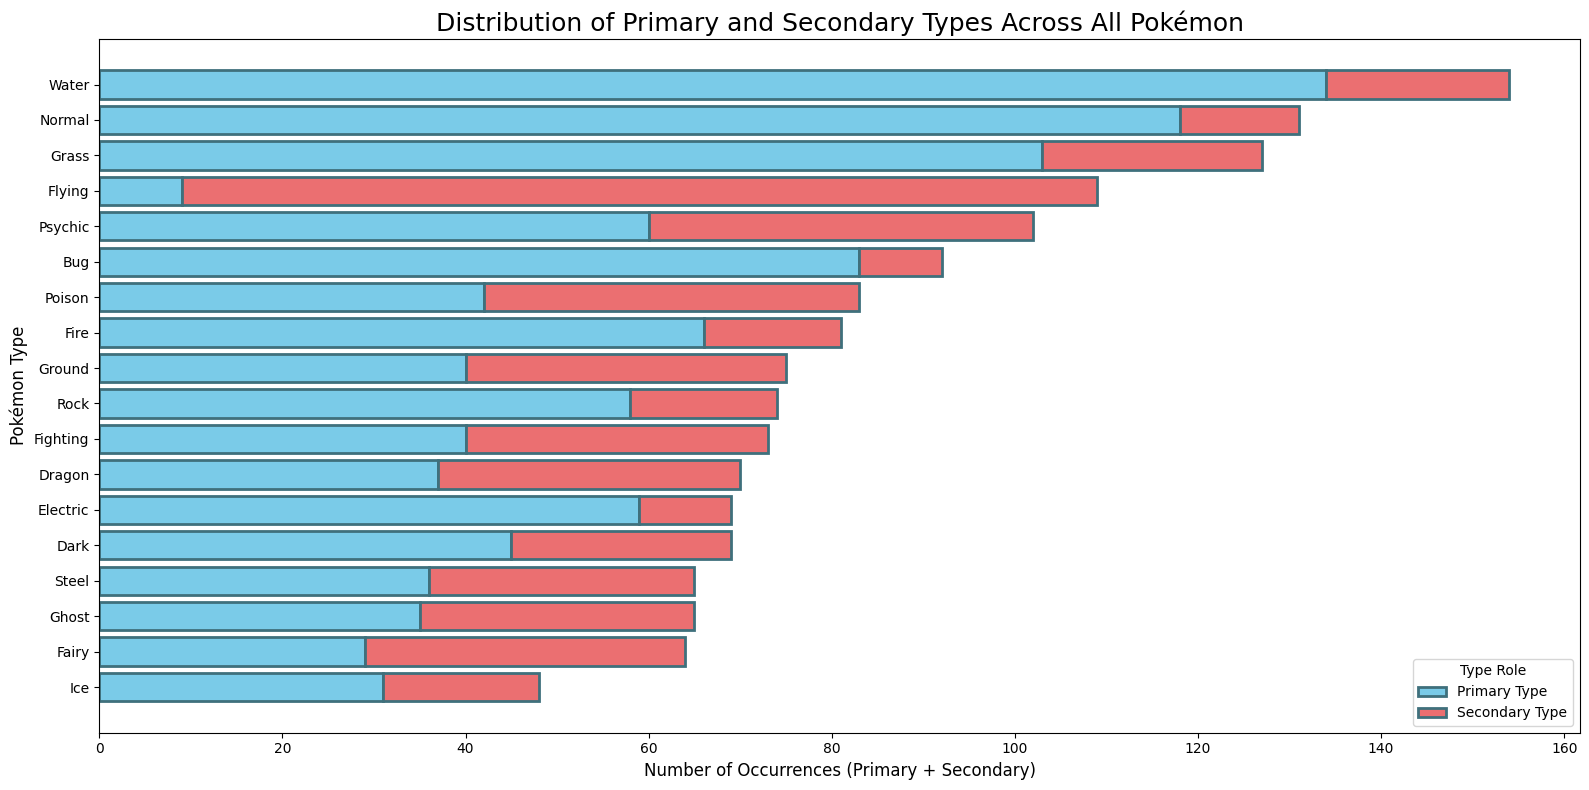

In [17]:
#fig, ax=plt.subplots(16,9)
plt.figure(figsize=(16, 8))

plt.barh(types_df_final['Typ'], types_df_final['Typ1'], 
         color='#7acbe8',
         label='Primary Type',
         edgecolor='#3f707c',
         linewidth=2)
    

plt.barh(types_df_final['Typ'], types_df_final['Typ2'], 
         left=types_df_final['Typ1'], 
         color='#eb6f71',
         edgecolor='#3f707c',
         linewidth=2,
         label='Secondary Type')

#..Dodawanie pokemona do wykresu - Feraligatr
img = plt.imread('images/images/160.png')
imagebox = OffsetImage(img, zoom=0.25) 
#..Oś x to daty -> punkt na współrzędnej X pd.Timestamp
ab = AnnotationBbox(imagebox, xy=(150, 2.45), frameon=False) 
#ax.add_artist(ab) 

plt.title('Distribution of Primary and Secondary Types Across All Pokémon', fontsize=18)
plt.xlabel('Number of Occurrences (Primary + Secondary)', fontsize=12)
plt.ylabel('Pokémon Type', fontsize=12)
plt.legend(title='Type Role')
plt.tight_layout()
plt.savefig('types.png')
plt.show()

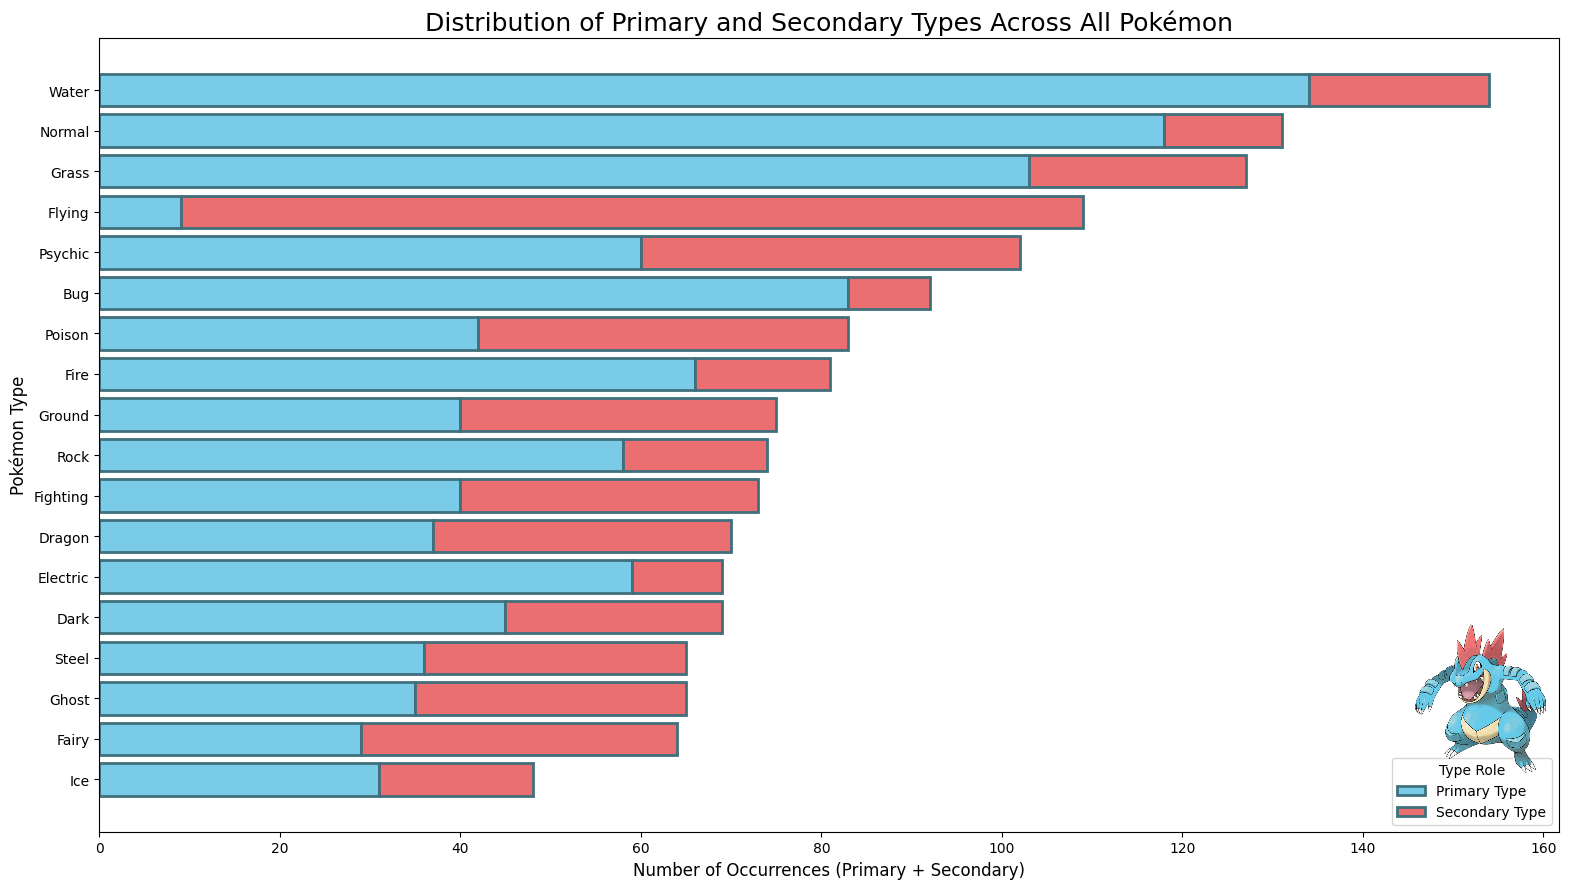

In [25]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.barh(types_df_final['Typ'], types_df_final['Typ1'], 
         color='#7acbe8',
         label='Primary Type',
         edgecolor='#3f707c',
         linewidth=2)

ax.barh(types_df_final['Typ'], types_df_final['Typ2'], 
         left=types_df_final['Typ1'], 
         color='#eb6f71',
         edgecolor='#3f707c',
         linewidth=2,
         label='Secondary Type')

#..Dodawanie pokemona do wykresu - Feraligator
img = plt.imread('images/images/160.png')
imagebox = OffsetImage(img, zoom=0.25) 
ab = AnnotationBbox(imagebox, xy=(153, 2), frameon=False, zorder=10) 
ax.add_artist(ab)


ax.set_title('Distribution of Primary and Secondary Types Across All Pokémon', fontsize=18)
ax.set_xlabel('Number of Occurrences (Primary + Secondary)', fontsize=12)
ax.set_ylabel('Pokémon Type', fontsize=12)
ax.legend(title='Type Role')

plt.tight_layout()
plt.savefig('types.png')
plt.show()